In [1]:
import os
import pygmt
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd
import itertools
from scipy.interpolate import griddata

import spherical as sph

In [2]:
def save_fit_results(model, filename="fit_results"):
    attrs = {}
    for key in ["residuals_", "dipole_moments_", "window_centers_", "source_coordinates_"]:
        if hasattr(model, key):
            attrs[key] = getattr(model, key)
    np.savez(f"{filename}.npz", **attrs, allow_pickle=True)

def load_fit_results(model, filename="fit_results"):
    data = np.load(f"{filename}.npz", allow_pickle=True)
    for key in data.files:
        value = data[key]
        if key == "source_coordinates_":
            value = tuple(value)
        setattr(model, key, value)
    return model

def deg_to_km(spacing_km):
    spacing_deg = spacing_km / 111.11
    return spacing_deg

def save_predict_results(coordinates, prediction, filename="predict_results"):

    np.savez(
        f"{filename}.npz",
        coordinates=coordinates,
        prediction=prediction,
        allow_pickle=True,
    )


def load_predict_results(filename="predict_results"):

    data = np.load(f"{filename}.npz", allow_pickle=True)

    coordinates = data["coordinates"]
    prediction = data["prediction"]

    return coordinates, prediction

In [3]:
caminho = "../data/parana-basin-magnetic-processed.csv"

df = pd.read_csv(caminho, sep=',', comment="#")
df.columns = ['FID','ESTACAO','LINHA','X','Y','LATITUDE','LONGITUDE','DATA','HORA','GPSALT','BARO',
              'MAGBRU','MAGCOM','MAGBASE','MAGCOR','MAGNIV','MAGMIC','MAGIGRF','IGRF','MDT']

prefixos = ('19', '29', '39')
df = df[~df['LINHA'].astype(str).str.startswith(prefixos)].copy()

In [4]:
inclination, declination = -25, -20 

grid_spacing = deg_to_km(1)
window_size = 1.5

grid_coord = bd.grid_coordinates((-56.8, -46.5, -25, -14), spacing= grid_spacing, non_dimensional_coords=500)
print(deg_to_km(1))

0.00900009000090001


## 0.06 block mean

In [5]:
# 006

# Scatter
coordinates_006_deep, deep_006 = load_predict_results("eqs_deep_predict_scatter_006")
coordinates_006_shallow, shallow_006 = load_predict_results("eqs_shallow_predict_scatter_006")

pred_total_006 = deep_006 + shallow_006

# Grid
coordinates_006_deep_grid, deep_grid_006 = load_predict_results("eqs_deep_predict_grid_006")
coordinates_006_shallow_grid, shallow_grid_006 = load_predict_results("eqs_shallow_predict_grid_006")

pred_grid_total_006 = deep_grid_006 + shallow_grid_006

#TFA
tfa_pred_total_006 = hm.total_field_anomaly(
    pred_total_006,
    inclination,
    declination,
)

tfa_006 = hm.total_field_anomaly(
    pred_grid_total_006,
    inclination,
    declination,
)

tfa_pred_grid_total_006 = vd.make_xarray_grid(
    grid_coord,
    tfa_006,
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

## 0.01 block mean

In [6]:
# 001

# Scatter
coordinates_001_deep, deep_001 = load_predict_results("eqs_deep_predict_scatter_001")
coordinates_001_shallow, shallow_001 = load_predict_results("eqs_shallow_predict_scatter_001")

pred_total_001 = deep_001 + shallow_001

# Grid
coordinates_001_deep_grid, deep_grid_001 = load_predict_results("eqs_deep_predict_grid_001")
coordinates_001_shallow_grid, shallow_grid_001 = load_predict_results("eqs_shallow_predict_grid_001")

pred_grid_total_001 = deep_grid_001 + shallow_grid_001

#TFA
tfa_pred_total_001 = hm.total_field_anomaly(
    pred_total_001,
    inclination,
    declination,
)

tfa_001 = hm.total_field_anomaly(
    pred_grid_total_001,
    inclination,
    declination,
)

tfa_pred_grid_total_001 = vd.make_xarray_grid(
    grid_coord,
    tfa_001,
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid


## 0.0023 block mean

In [7]:
# 00023

# Scatter
coordinates_00023_deep, deep_00023 = load_predict_results("eqs_deep_predict_scatter_00023")
coordinates_00023_shallow, shallow_00023 = load_predict_results("eqs_shallow_predict_scatter_00023")

pred_total_00023 = deep_00023 + shallow_00023


# Grid
coordinates_00023_deep_grid, deep_grid_00023 = load_predict_results("eqs_deep_predict_grid_00023")
coordinates_00023_shallow_grid, shallow_grid_00023 = load_predict_results("eqs_shallow_predict_grid_00023")

pred_grid_total_00023 = deep_grid_00023 + shallow_grid_00023

#TFA
tfa_pred_total_00023 = hm.total_field_anomaly(
    pred_total_00023,
    inclination,
    declination,
)

tfa_00023 = hm.total_field_anomaly(
    pred_grid_total_00023,
    inclination,
    declination,
)

tfa_pred_grid_total_00023 = vd.make_xarray_grid(
    grid_coord,
    tfa_00023,
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid


## Full data 

In [8]:
# FULL

# Scatter
coordinates_full_deep, deep_full = load_predict_results("eqs_deep_predict_scatter_full")
coordinates_full_shallow, shallow_full = load_predict_results("eqs_shallow_predict_scatter_full")

pred_total_full = deep_full + shallow_full


# Grid
coordinates_full_deep_grid, deep_grid_full = load_predict_results("eqs_deep_predict_grid_full")
coordinates_full_shallow_grid, shallow_grid_full = load_predict_results("eqs_shallow_predict_grid_full")

pred_grid_total_full = deep_grid_full + shallow_grid_full

#TFA
tfa_pred_total_full = hm.total_field_anomaly(
    pred_total_full,
    inclination,
    declination,
)

tfa_full = hm.total_field_anomaly(
    pred_grid_total_full,
    inclination,
    declination,
)

tfa_pred_grid_total_full = vd.make_xarray_grid(
    grid_coord,
    tfa_full,
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

In [9]:
shapefile_brasil = "../../../.cache/pooch//BR_UF_2022/BR_UF_2022.shp"


required_extensions = ['.shp', '.shx', '.dbf']
base_name = os.path.splitext(shapefile_brasil)[0]

missing_files = []
for ext in required_extensions:
    file_path = f"{base_name}{ext}"
    if not os.path.exists(file_path):
        missing_files.append(file_path)

if missing_files:
    print(f"Erro: Os seguintes arquivos obrigatórios estão faltando: {', '.join(missing_files)}")
    exit()


try:
    brasil = gpd.read_file(shapefile_brasil)
except Exception as e:
    print(f"Erro ao carregar o shapefile: {e}")
    exit()



brasil_reduc = brasil.simplify(0.05)

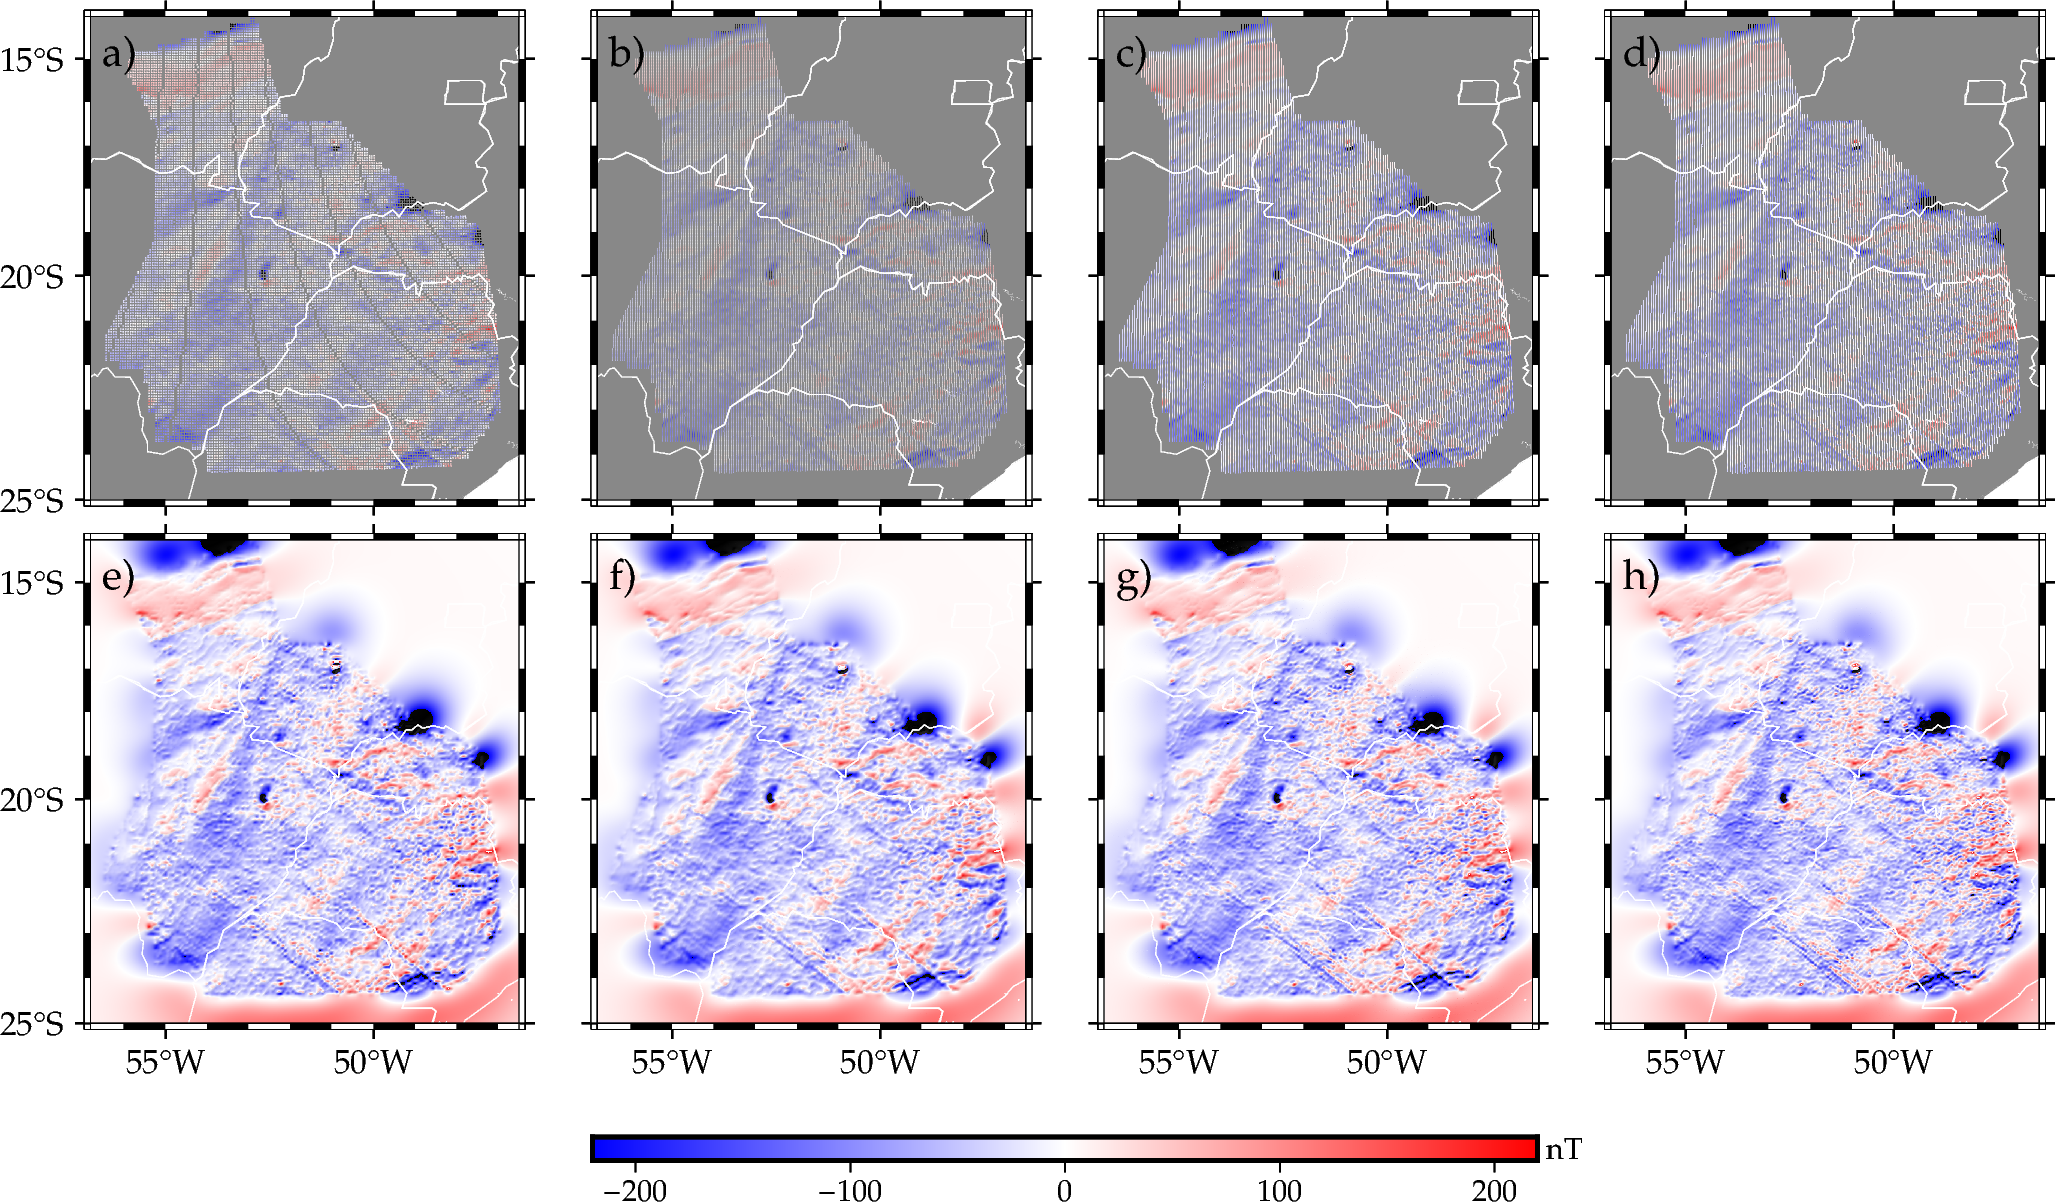

In [10]:
region = [-56.8, -46.5, -25, -14]
scale = 220
fig = pygmt.Figure()

with pygmt.config(FONT="10p,Palatino-Roman",
    FONT_ANNOT="8p,Palatino-Roman",
    FONT_ANNOT_PRIMARY="8p,Palatino-Roman",
    FONT_ANNOT_SECONDARY="8p,Palatino-Roman",
    MAP_FRAME_WIDTH="1.5p",
    MAP_TITLE_OFFSET="-2p", ):

    pygmt.makecpt(cmap="polar", series=[-scale, scale])

    with fig.subplot(nrows=2,
            ncols=4,
            figsize=("16.5c", "8.8c"),
            autolabel="+jTL+o0.1/0.3c",
            margins='0.2c/-0.1c',
            sharex="b",
            sharey="l"):
        
        with fig.set_panel(panel=0):

            fig.coast(
                    land="#888888",
                    region = region,
                    projection="M?",
                )

            fig.plot(
                    x=coordinates_006_shallow[0],
                    y=coordinates_006_shallow[1],
                    fill=tfa_pred_total_006,
                    style="c0.01c",
                    cmap=True
            )

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )


        with fig.set_panel(panel=1):

            fig.coast(
                    land="#888888",
                    region = region,
                    projection="M?",
            )
            
            fig.plot(
                x=coordinates_001_shallow[0],
                y=coordinates_001_shallow[1],
                fill=tfa_pred_total_001,
                style="c0.001c",
                projection="M?",
                cmap=True
            )

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=2):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.plot(
                    x=coordinates_00023_shallow[0],
                    y=coordinates_00023_shallow[1],
                    fill=tfa_pred_total_00023,
                    style="c0.001c",
                    cmap=True
            )     

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=3):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.plot(
                    x=coordinates_full_shallow[0],
                    y=coordinates_full_shallow[1],
                    fill=tfa_pred_total_full,
                    style="c0.001c",
                    cmap=True
            )     

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=4):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.grdimage(
            grid=tfa_pred_grid_total_006,
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )       

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=5):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.grdimage(
            grid=tfa_pred_grid_total_001,
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )       

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=6):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.grdimage(
            grid=tfa_pred_grid_total_00023,
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )       

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=7):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.grdimage(
            grid=tfa_pred_grid_total_full,
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )       

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

pygmt.config(FONT_ANNOT_PRIMARY="10p,Palatino-Roman", FONT_ANNOT_SECONDARY="10p,Palatino-Roman")
fig.colorbar(position="JBC+w8/0.2c+h", frame=["y+lnT", 'a'])
fig.show(width=7000)
fig.savefig(fname='../paper/figures/comparison-blockreduce.jpeg',transparent=False)